In [1]:
# poker_baseline.ipynb

# Cell 1: Setup
import requests
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Config
CONFIG = {
    'n_files': None,  # None = 전체 사용
    'batch_size': 64,  # 데이터 많으니 배치 사이즈도 키움
    'learning_rate': 0.0005,
    'n_epochs': 15,  # epoch도 좀 늘림
    'hidden_dims': [512, 512, 256, 128],
    'test_size': 0.2,
    'random_seed': 42,
    'use_local': True,
    'local_root': r'F:\workspace\poker-hand-histories\data',  # ★ raw string
    'allowed_variants': ['NT', 'FT'],
    'min_players': 3,
    'local_cache_file': 'local_data_cache.pkl',
}

# Set random seeds
np.random.seed(CONFIG['random_seed'])
torch.manual_seed(CONFIG['random_seed'])

print("✓ Setup complete")
print(f"Config: {CONFIG}")

✓ Setup complete
Config: {'n_files': None, 'batch_size': 64, 'learning_rate': 0.0005, 'n_epochs': 15, 'hidden_dims': [512, 512, 256, 128], 'test_size': 0.2, 'random_seed': 42, 'use_local': True, 'local_root': 'F:\\workspace\\poker-hand-histories\\data', 'allowed_variants': ['NT', 'FT'], 'min_players': 3, 'local_cache_file': 'local_data_cache.pkl'}


In [2]:
# Cell 2: Data fetching (local-first, with filtering and caching)
import pickle
import os
import glob

CACHE_FILE = 'pluribus_data_cache.pkl'  # legacy cache for remote

def _should_keep_by_filters(phh_text):
    # Use existing parser to extract variant and players
    hand = parse_phh_hand(phh_text)
    variant = hand.get('variant')
    players = hand.get('players', [])
    actions = hand.get('actions', [])

    # 1) 텍스트에 '????'가 하나라도 있으면 제외 (가장 보수적)
    if "????" in phh_text:
        return False

    # 2) 액션에 미상 토큰이 섞여 있으면 제외 (보다 의미적)
    if any("????" in a for a in actions):
        return False

    if variant is None or not players:
        return False
    if len(players) < CONFIG.get('min_players', 3):
        return False
    allowed = set(CONFIG.get('allowed_variants', ['NT','FT']))
    return variant in allowed

def _load_local_phh_files(root_dir, n_files=None, use_cache=True):
    cache_path = CONFIG.get('local_cache_file', 'local_data_cache.pkl')
    if use_cache and os.path.exists(cache_path):
        print(f"Loading from local cache: {cache_path}")
        with open(cache_path, 'rb') as f:
            cached = pickle.load(f)
        print(f"✓ Loaded {len(cached)} files from local cache")
        return cached[:n_files] if n_files is not None else cached

    # Gather files recursively; support .phh and .phhs
    patterns = [os.path.join(root_dir, '**', '*.phh'),
                os.path.join(root_dir, '**', '*.phhs'),
                os.path.join(root_dir, '**', '*.PHH'),
                os.path.join(root_dir, '**', '*.PHHS')]
    candidates = []
    for pat in patterns:
        candidates.extend(glob.glob(pat, recursive=True))

    print(f"Found {len(candidates)} candidate PHH files under {root_dir}")
    phh_texts = []
    kept = 0

    for path in candidates:
        try:
            with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                text = f.read()
        except Exception as e:
            print(f'  [skip] {path}: {e}')
            continue

        if _should_keep_by_filters(text):
            phh_texts.append(text)
            kept += 1
            if n_files is not None and kept >= n_files:
                break

            if kept % 500 == 0:
                print(f'  → kept so far: {kept}')

    print(f'✓ Kept {kept} PHH files after filters (players>={CONFIG["min_players"]}, variant in {CONFIG["allowed_variants"]})')

    # Save cache
    if use_cache:
        with open(cache_path, 'wb') as f:
            pickle.dump(phh_texts, f)
        print(f'Local cache saved -> {cache_path}')

    return phh_texts

# Backward-compatible function name used elsewhere
def download_pluribus_files(n_files=None, use_cache=True):
    """
    If CONFIG['use_local'] is True, load from local folder with filters.
    Otherwise, fall back to the original remote download (disabled here).
    """
    if CONFIG.get('use_local', False):
        root = CONFIG.get('local_root', '.')
        print(f'[Local mode] Reading PHH from: {root}')
        return _load_local_phh_files(root, n_files=n_files, use_cache=use_cache)

    # If not local, raise a clear error (or implement remote again if needed)
    raise RuntimeError("Remote download disabled in this modified notebook. Set CONFIG['use_local']=True and provide CONFIG['local_root'].")


In [3]:
# Cell 3: Parsing functions
def parse_phh_hand(phh_text):
    """Parse PHH text into structured data"""
    hand = {}
    
    variant_match = re.search(r"variant = '(\w+)'", phh_text)
    if variant_match:
        hand['variant'] = variant_match.group(1)
    
    antes_match = re.search(r"antes = \[([\d, ]+)\]", phh_text)
    if antes_match:
        hand['antes'] = [int(x.strip()) for x in antes_match.group(1).split(',')]
    
    blinds_match = re.search(r"blinds_or_straddles = \[([\d, ]+)\]", phh_text)
    if blinds_match:
        hand['blinds'] = [int(x.strip()) for x in blinds_match.group(1).split(',')]
    
    stacks_match = re.search(r"starting_stacks = \[([\d, ]+)\]", phh_text)
    if stacks_match:
        hand['starting_stacks'] = [int(x.strip()) for x in stacks_match.group(1).split(',')]
    
    actions_match = re.search(r"actions = \[(.*?)\]", phh_text, re.DOTALL)
    if actions_match:
        actions_str = actions_match.group(1)
        action_list = re.findall(r"'([^']+)'", actions_str)
        hand['actions'] = action_list
    
    players_match = re.search(r"players = \[(.*?)\]", phh_text)
    if players_match:
        players_str = players_match.group(1)
        hand['players'] = [p.strip().strip("'") for p in players_str.split(',')]
    
    return hand

def parse_cards(card_str):
    """Parse card string into list of cards (e.g., 'TcQc' -> ['Tc', 'Qc'])"""
    cards = []
    i = 0
    while i < len(card_str):
        if i + 1 < len(card_str):
            cards.append(card_str[i:i+2])
            i += 2
        else:
            i += 1
    return cards

print("✓ Parsing functions ready")

✓ Parsing functions ready


In [4]:
# Cell 4: Feature extraction
def card_to_index(card):
    """Convert card to 0-51 index"""
    if len(card) != 2:
        return -1
    
    rank_map = {'2': 0, '3': 1, '4': 2, '5': 3, '6': 4, '7': 5, '8': 6, 
                '9': 7, 'T': 8, 'J': 9, 'Q': 10, 'K': 11, 'A': 12}
    suit_map = {'c': 0, 'd': 1, 'h': 2, 's': 3}
    
    rank = card[0]
    suit = card[1]
    
    if rank in rank_map and suit in suit_map:
        return rank_map[rank] * 4 + suit_map[suit]
    return -1

def state_to_features(state):
    """
    Convert game state to feature vector (377-dim)
    - Hole cards: 104 dim (52 * 2)
    - Board cards: 260 dim (52 * 5)
    - Position: 6 dim
    - Street: 4 dim
    - Numeric: 3 dim (pot, stack, bet_to_call)
    """
    features = []
    
    # Hole cards
    hole_cards_vec = np.zeros(104)
    hole_cards = state['hole_cards']
    for i, card in enumerate(hole_cards[:2]):
        idx = card_to_index(card)
        if idx >= 0:
            hole_cards_vec[i * 52 + idx] = 1
    features.extend(hole_cards_vec)
    
    # Board cards
    board_cards_vec = np.zeros(260)
    board_cards = state['board_cards']
    for i, card in enumerate(board_cards[:5]):
        idx = card_to_index(card)
        if idx >= 0:
            board_cards_vec[i * 52 + idx] = 1
    features.extend(board_cards_vec)
    
    # Position
    position_vec = np.zeros(6)
    if 0 <= state['position'] < 6:
        position_vec[state['position']] = 1
    features.extend(position_vec)
    
    # Street
    street_map = {'preflop': 0, 'flop': 1, 'turn': 2, 'river': 3}
    street_vec = np.zeros(4)
    if state['street'] in street_map:
        street_vec[street_map[state['street']]] = 1
    features.extend(street_vec)
    
    # Numeric features (normalized by 10000 chips)
    pot_norm = state['pot'] / 10000.0
    stack_norm = state['stack'] / 10000.0
    bet_to_call_norm = state['bet_to_call'] / 10000.0
    features.extend([pot_norm, stack_norm, bet_to_call_norm])
    
    return np.array(features)

print("✓ Feature extraction ready")

✓ Feature extraction ready


In [5]:
# Cell 5: Action labeling
def categorize_action(action_type, action_amount, bet_to_call, pot, stack):
    """
    Categorize action into discrete classes:
    0: fold
    1: check_call
    2: raise_small (< 0.5x pot)
    3: raise_medium (0.5-1.5x pot)
    4: raise_large (> 1.5x pot)
    5: all_in
    """
    if action_type == 'f':
        return 0
    elif action_type == 'cc':
        return 1
    elif action_type == 'cbr':
        raise_amount = action_amount - bet_to_call
        
        if raise_amount >= stack * 0.95:
            return 5
        
        if raise_amount < pot * 0.5:
            return 2
        elif raise_amount < pot * 1.5:
            return 3
        else:
            return 4
    else:
        return -1

ACTION_NAMES = ['fold', 'check_call', 'raise_small', 'raise_medium', 'raise_large', 'all_in']

print("✓ Action labeling ready")

✓ Action labeling ready


In [6]:
# Cell 6: Decision point extraction
def extract_decision_points(hand, target_player='p1'):
    """Extract all decision points for a target player"""
    actions = hand.get('actions', [])
    n_players = len(hand.get('players', []))
    starting_stacks = hand.get('starting_stacks', [])
    blinds = hand.get('blinds', [])
    
    current_stacks = starting_stacks.copy()
    current_pot = sum(blinds)
    hole_cards = {}
    board_cards = []
    current_bets = blinds.copy()
    street = 'preflop'
    
    decision_points = []
    
    for action in actions:
        parts = action.split()
        
        if parts[0] == 'd':
            if parts[1] == 'dh':
                player = parts[2]
                if len(parts) > 3:
                    cards_str = parts[3]
                    hole_cards[player] = parse_cards(cards_str)
            elif parts[1] == 'db':
                if len(parts) > 2:
                    cards_str = parts[2]
                    new_cards = parse_cards(cards_str)
                    
                    prev_board_len = len(board_cards)
                    board_cards.extend(new_cards)
                    
                    if prev_board_len < 3 and len(board_cards) >= 3:
                        street = 'flop'
                        current_bets = [0] * n_players
                    elif prev_board_len < 4 and len(board_cards) >= 4:
                        street = 'turn'
                        current_bets = [0] * n_players
                    elif prev_board_len < 5 and len(board_cards) >= 5:
                        street = 'river'
                        current_bets = [0] * n_players
        
        elif parts[0].startswith('p'):
            player = parts[0]
            player_idx = int(player[1:]) - 1
            
            if player == target_player:
                state = {
                    'street': street,
                    'hole_cards': hole_cards.get(player, []),
                    'board_cards': board_cards.copy(),
                    'pot': current_pot,
                    'stack': current_stacks[player_idx],
                    'current_bet': current_bets[player_idx],
                    'bet_to_call': max(current_bets) - current_bets[player_idx],
                    'position': player_idx,
                    'n_players': n_players,
                }
                
                action_type = parts[1] if len(parts) > 1 else 'unknown'
                action_amount = int(parts[2]) if len(parts) > 2 and parts[2].isdigit() else 0
                
                decision_points.append({
                    'state': state,
                    'action_type': action_type,
                    'action_amount': action_amount,
                })
            
            if len(parts) > 1:
                action_type = parts[1]
                
                if action_type == 'f':
                    pass
                elif action_type == 'cc':
                    amount_to_call = max(current_bets) - current_bets[player_idx]
                    current_stacks[player_idx] -= amount_to_call
                    current_bets[player_idx] += amount_to_call
                    current_pot += amount_to_call
                elif action_type == 'cbr':
                    total_bet = int(parts[2])
                    amount_to_add = total_bet - current_bets[player_idx]
                    current_stacks[player_idx] -= amount_to_add
                    current_bets[player_idx] = total_bet
                    current_pot += amount_to_add

    return decision_points

print("✓ Decision point extraction ready")

✓ Decision point extraction ready


In [7]:
import requests
from datetime import datetime

response = requests.get("https://api.github.com/repos/uoftcprg/phh-dataset")
reset_time = int(response.headers.get('X-RateLimit-Reset', 0))
remaining = response.headers.get('X-RateLimit-Remaining', 'Unknown')

print(f"Remaining requests: {remaining}")
if reset_time:
    reset_dt = datetime.fromtimestamp(reset_time)
    print(f"Resets at: {reset_dt}")
    print(f"Time until reset: {reset_dt - datetime.now()}")

Remaining requests: 59
Resets at: 2025-11-04 23:25:39
Time until reset: 0:59:58.671575


In [8]:
# Cell 7: Download and process data
print("Downloading data...")
phh_texts = download_pluribus_files(
    n_files=CONFIG['n_files']
    #use_cache=False,          # ★ 캐시 사용 안 함
)
print(f"✓ Downloaded {len(phh_texts)} files")

print("\nExtracting decision points...")
all_X = []
all_y = []

for phh_text in phh_texts:
    hand = parse_phh_hand(phh_text)
    
    # Extract from all players
    for player_idx in range(1, len(hand.get('players', [])) + 1):
        target_player = f'p{player_idx}'
        decision_points = extract_decision_points(hand, target_player=target_player)
        
        for dp in decision_points:
            features = state_to_features(dp['state'])
            label = categorize_action(
                dp['action_type'],
                dp['action_amount'],
                dp['state']['bet_to_call'],
                dp['state']['pot'],
                dp['state']['stack']
            )
            
            if label >= 0:
                all_X.append(features)
                all_y.append(label)

X = np.array(all_X)
y = np.array(all_y)

print(f"✓ Extracted {len(X)} decision points")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

# Label distribution
unique, counts = np.unique(y, return_counts=True)
print("\nLabel distribution:")
for label, count in zip(unique, counts):
    print(f"  {ACTION_NAMES[label]}: {count} ({count/len(y)*100:.1f}%)")

[Local mode] Reading PHH from: F:\workspace\poker-hand-histories\data
Found 553972 candidate PHH files under F:\workspace\poker-hand-histories\data
  → kept so far: 500
  → kept so far: 1000
  → kept so far: 1500
  → kept so far: 2000
  → kept so far: 2500
  → kept so far: 3000
  → kept so far: 3500
  → kept so far: 4000
  → kept so far: 4500
  → kept so far: 5000
  → kept so far: 5500
  → kept so far: 6000
  → kept so far: 6500
  → kept so far: 7000
  → kept so far: 7500
  → kept so far: 8000
  → kept so far: 8500
  → kept so far: 9000
  → kept so far: 9500
  → kept so far: 10000
  → kept so far: 10500
  → kept so far: 11000
  → kept so far: 11500
  → kept so far: 12000
  → kept so far: 12500
  → kept so far: 13000
  → kept so far: 13500
  → kept so far: 14000
  → kept so far: 14500
  → kept so far: 15000
  → kept so far: 15500
  → kept so far: 16000
  → kept so far: 16500
  → kept so far: 17000
  → kept so far: 17500
  → kept so far: 18000
  → kept so far: 18500
  → kept so far: 1900

In [9]:
# Cell 8: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'], random_state=CONFIG['random_seed']
)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'])

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

Train size: 1047833
Test size: 261959


In [10]:
# Cell 9: Model definition
class PokerMLP(nn.Module):
    def __init__(self, input_dim=377, hidden_dims=[256, 128, 64], output_dim=6):
        super(PokerMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

model = PokerMLP(
    input_dim=377,
    hidden_dims=CONFIG['hidden_dims'],
    output_dim=6
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

total_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {total_params:,} parameters")

Model created with 621,190 parameters


In [11]:
# Cell 10: Training
print("Training...")
train_losses = []
train_accs = []

for epoch in range(CONFIG['n_epochs']):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()
    
    avg_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total
    
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    
    print(f"Epoch {epoch+1}/{CONFIG['n_epochs']}: Loss={avg_loss:.4f}, Acc={train_acc:.2f}%")

print("\n✓ Training complete")

Training...
Epoch 1/15: Loss=0.8462, Acc=62.84%
Epoch 2/15: Loss=0.7722, Acc=65.33%
Epoch 3/15: Loss=0.7539, Acc=65.92%
Epoch 4/15: Loss=0.7415, Acc=66.42%
Epoch 5/15: Loss=0.7270, Acc=67.14%
Epoch 6/15: Loss=0.7107, Acc=67.99%
Epoch 7/15: Loss=0.7024, Acc=68.54%
Epoch 8/15: Loss=0.6896, Acc=68.99%
Epoch 9/15: Loss=0.6782, Acc=69.40%
Epoch 10/15: Loss=0.6714, Acc=69.81%
Epoch 11/15: Loss=0.6690, Acc=70.14%
Epoch 12/15: Loss=0.6609, Acc=70.36%
Epoch 13/15: Loss=0.6569, Acc=70.62%
Epoch 14/15: Loss=0.6519, Acc=70.78%
Epoch 15/15: Loss=0.6471, Acc=70.97%

✓ Training complete


In [12]:
# Cell 11: Evaluation (수정)
model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        test_total += y_batch.size(0)
        test_correct += (predicted == y_batch).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%\n")

# Classification report (labels 파라미터 추가)
print("Classification Report:")
print(classification_report(
    all_labels, 
    all_preds, 
    labels=list(range(6)),  # 0-5 모든 클래스 명시
    target_names=ACTION_NAMES, 
    zero_division=0
))

Test Accuracy: 71.91%

Classification Report:
              precision    recall  f1-score   support

        fold       0.81      0.79      0.80     54070
  check_call       0.68      0.79      0.73    115984
 raise_small       0.68      0.54      0.60     59936
raise_medium       0.79      0.68      0.73     30796
 raise_large       0.56      0.55      0.55      1087
      all_in       0.53      0.84      0.65        86

    accuracy                           0.72    261959
   macro avg       0.68      0.70      0.68    261959
weighted avg       0.72      0.72      0.72    261959



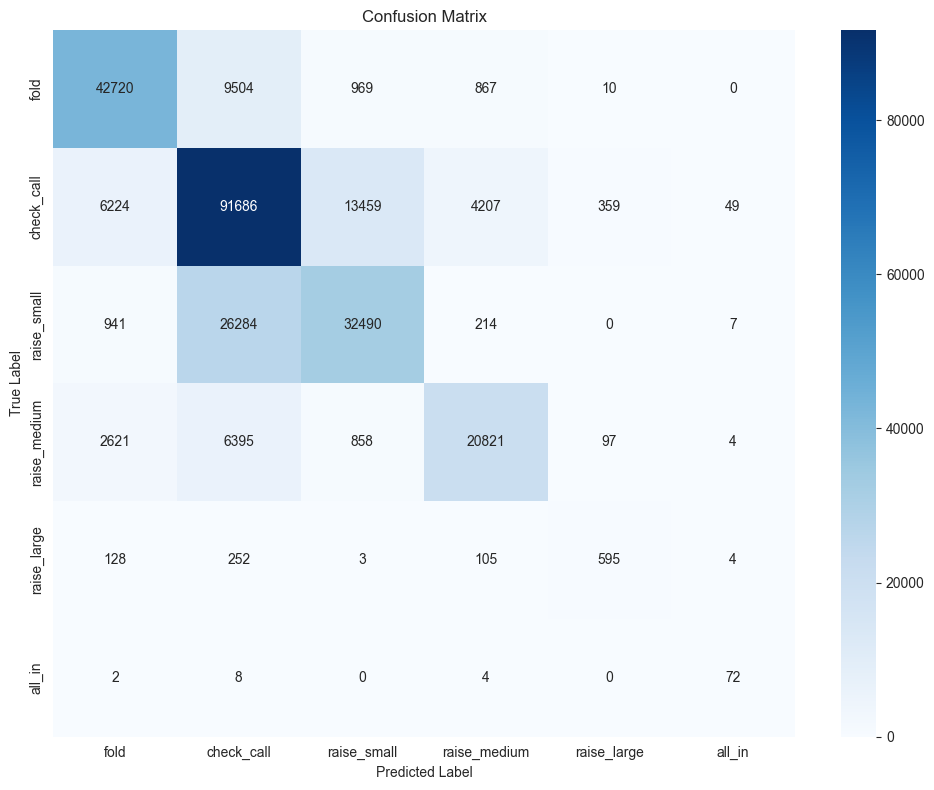

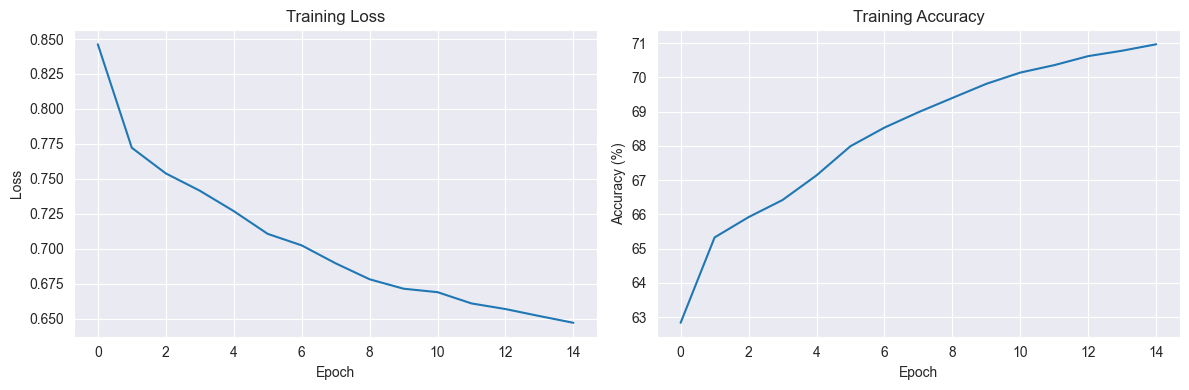

In [13]:
# Cell 12: Confusion matrix visualization
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=ACTION_NAMES, yticklabels=ACTION_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(train_accs)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
!pip install treys

In [15]:
# Cell 13: Poker Environment
from treys import Card, Evaluator, Deck

class PokerGame:
    """6-player No-Limit Texas Hold'em Environment (Pluribus settings)"""
    
    def __init__(self, n_players=6, starting_stack=10000, small_blind=50, big_blind=100):
        self.n_players = n_players
        self.starting_stack = starting_stack
        self.small_blind = small_blind
        self.big_blind = big_blind
        self.evaluator = Evaluator()
        self.reset()
    
    def reset(self):
        """Start a new hand"""
        self.deck = Deck()
        self.stacks = [self.starting_stack] * self.n_players
        self.pot = 0
        self.current_bets = [0] * self.n_players
        self.hole_cards = [[] for _ in range(self.n_players)]
        self.board_cards = []
        self.folded = [False] * self.n_players
        self.street = 'preflop'
        self.button = 0
        
        # Post blinds
        sb_pos = (self.button + 1) % self.n_players
        bb_pos = (self.button + 2) % self.n_players
        self.current_bets[sb_pos] = self.small_blind
        self.current_bets[bb_pos] = self.big_blind
        self.stacks[sb_pos] -= self.small_blind
        self.stacks[bb_pos] -= self.big_blind
        self.pot = self.small_blind + self.big_blind
        
        # Deal hole cards
        for i in range(self.n_players):
            self.hole_cards[i] = [self.deck.draw(1)[0], self.deck.draw(1)[0]]
        
        return self.get_state(0)
    
    def get_state(self, player_idx):
        """Get state from player's perspective"""
        return {
            'street': self.street,
            'hole_cards': self.hole_cards[player_idx],
            'board_cards': self.board_cards.copy(),
            'pot': self.pot,
            'stack': self.stacks[player_idx],
            'current_bet': self.current_bets[player_idx],
            'bet_to_call': max(self.current_bets) - self.current_bets[player_idx],
            'position': player_idx,
            'n_players': self.n_players,
        }
    
    def step(self, player_idx, action_type, amount=0):
        """Execute an action"""
        if self.folded[player_idx]:
            return
        
        if action_type == 'fold':
            self.folded[player_idx] = True
        elif action_type == 'call':
            call_amount = max(self.current_bets) - self.current_bets[player_idx]
            call_amount = min(call_amount, self.stacks[player_idx])
            self.stacks[player_idx] -= call_amount
            self.current_bets[player_idx] += call_amount
            self.pot += call_amount
        elif action_type == 'raise':
            additional = amount - self.current_bets[player_idx]
            additional = min(additional, self.stacks[player_idx])
            self.stacks[player_idx] -= additional
            self.current_bets[player_idx] += additional
            self.pot += additional
    
    def advance_street(self):
        """Move to next betting round"""
        self.current_bets = [0] * self.n_players
        
        if self.street == 'preflop':
            self.board_cards = self.deck.draw(3)
            self.street = 'flop'
        elif self.street == 'flop':
            self.board_cards.extend(self.deck.draw(1))
            self.street = 'turn'
        elif self.street == 'turn':
            self.board_cards.extend(self.deck.draw(1))
            self.street = 'river'
        elif self.street == 'river':
            self.street = 'showdown'
    
    def is_betting_round_over(self):
        """Check if current betting round is complete"""
        active_players = [i for i in range(self.n_players) if not self.folded[i]]
        if len(active_players) <= 1:
            return True
        
        max_bet = max(self.current_bets)
        for i in active_players:
            if self.current_bets[i] < max_bet and self.stacks[i] > 0:
                return False
        return True
    
    def get_winners(self):
        """Determine winners and distribute pot"""
        active_players = [i for i in range(self.n_players) if not self.folded[i]]
        
        if len(active_players) == 1:
            return {active_players[0]: self.pot}
        
        # Showdown
        best_rank = float('inf')
        winners = []
        
        for player_idx in active_players:
            hand = self.hole_cards[player_idx]
            rank = self.evaluator.evaluate(self.board_cards, hand)
            
            if rank < best_rank:
                best_rank = rank
                winners = [player_idx]
            elif rank == best_rank:
                winners.append(player_idx)
        
        pot_per_winner = self.pot / len(winners)
        return {winner: pot_per_winner for winner in winners}

print("✓ Poker environment ready")

✓ Poker environment ready


In [16]:
# Cell 14: Rule-based Bots
class BaseBot:
    """Base class for poker bots"""
    def __init__(self, name):
        self.name = name
    
    def get_action(self, state, game):
        """Return (action_type, amount)"""
        raise NotImplementedError

class RandomBot(BaseBot):
    """Makes random legal actions"""
    def get_action(self, state, game):
        actions = ['fold', 'call', 'raise']
        action = np.random.choice(actions)
        
        if action == 'raise':
            # Random raise between min_raise and all-in
            min_raise = max(game.current_bets) + game.big_blind
            max_raise = state['stack'] + state['current_bet']
            if min_raise >= max_raise:
                action = 'call'
            else:
                amount = np.random.randint(min_raise, max_raise + 1)
                return ('raise', amount)
        
        return (action, 0)

class TightPassiveBot(BaseBot):
    """Only plays good hands, rarely raises"""
    def get_action(self, state, game):
        # Simple hand strength: check for pairs, high cards
        hole_cards = state['hole_cards']
        
        # Extract ranks (treys uses bit representation)
        rank1 = Card.get_rank_int(hole_cards[0])
        rank2 = Card.get_rank_int(hole_cards[1])
        
        is_pair = (rank1 == rank2)
        has_high_card = (rank1 >= 9 or rank2 >= 9)  # Jack or better
        
        bet_to_call = state['bet_to_call']
        
        # Tight: fold weak hands if facing bet
        if not is_pair and not has_high_card and bet_to_call > 0:
            return ('fold', 0)
        
        # Passive: mostly call, rarely raise
        if np.random.random() < 0.9:  # 90% call
            return ('call', 0)
        else:  # 10% small raise
            min_raise = max(game.current_bets) + game.big_blind
            amount = min(min_raise + state['pot'] // 2, state['stack'] + state['current_bet'])
            return ('raise', amount)

class LooseAggressiveBot(BaseBot):
    """Plays many hands, raises frequently"""
    def get_action(self, state, game):
        bet_to_call = state['bet_to_call']
        
        # Loose: rarely fold
        if bet_to_call > state['stack'] * 0.5:  # Only fold to huge bets
            if np.random.random() < 0.3:
                return ('fold', 0)
        
        # Aggressive: frequently raise
        if np.random.random() < 0.6:  # 60% raise
            # Raise between 0.5x and 2x pot
            raise_size = np.random.uniform(0.5, 2.0) * state['pot']
            min_raise = max(game.current_bets) + game.big_blind
            amount = int(max(min_raise, raise_size))
            amount = min(amount, state['stack'] + state['current_bet'])
            return ('raise', amount)
        else:
            return ('call', 0)

class CallStationBot(BaseBot):
    """Almost never folds, mostly calls"""
    def get_action(self, state, game):
        bet_to_call = state['bet_to_call']
        
        # Only fold to all-in when holding nothing
        if bet_to_call >= state['stack'] * 0.8:
            if np.random.random() < 0.2:  # 20% fold
                return ('fold', 0)
        
        # Mostly call
        if np.random.random() < 0.95:  # 95% call
            return ('call', 0)
        else:  # 5% small raise
            min_raise = max(game.current_bets) + game.big_blind
            amount = min(min_raise + state['pot'] // 3, state['stack'] + state['current_bet'])
            return ('raise', amount)

print("✓ Rule-based bots ready")
print("  - RandomBot: Random actions")
print("  - TightPassiveBot: Good hands, rarely raises")
print("  - LooseAggressiveBot: Many hands, frequent raises")
print("  - CallStationBot: Almost never folds")

✓ Rule-based bots ready
  - RandomBot: Random actions
  - TightPassiveBot: Good hands, rarely raises
  - LooseAggressiveBot: Many hands, frequent raises
  - CallStationBot: Almost never folds


In [17]:
# Cell 15: Model Player Wrapper (수정)
class ModelPlayer(BaseBot):
    """Wrapper for trained MLP model"""
    def __init__(self, model, name="ModelPlayer"):
        super().__init__(name)
        self.model = model
        self.model.eval()
    
    def card_to_index(self, card):
        """Convert treys card to 0-51 index"""
        # treys uses: rank 0-12 (deuce to ace), suit 1,2,4,8 (spades, hearts, diamonds, clubs)
        rank = Card.get_rank_int(card)  # 0-12
        suit_int = Card.get_suit_int(card)  # 1, 2, 4, or 8
        
        # Convert suit to 0-3
        suit_map = {1: 0, 2: 1, 4: 2, 8: 3}  # spades, hearts, diamonds, clubs
        suit = suit_map.get(suit_int, 0)
        
        # 0-51 index
        return rank * 4 + suit
    
    def state_to_features(self, state):
        """Convert state to feature vector (same as training)"""
        features = []
        
        # Hole cards (104 dim)
        hole_cards_vec = np.zeros(104)
        for i, card in enumerate(state['hole_cards'][:2]):
            idx = self.card_to_index(card)
            if 0 <= idx < 52:
                hole_cards_vec[i * 52 + idx] = 1
        features.extend(hole_cards_vec)
        
        # Board cards (260 dim)
        board_cards_vec = np.zeros(260)
        board_cards = state['board_cards']
        for i, card in enumerate(board_cards[:5]):
            idx = self.card_to_index(card)
            if 0 <= idx < 52:
                board_cards_vec[i * 52 + idx] = 1
        features.extend(board_cards_vec)
        
        # Position (6 dim)
        position_vec = np.zeros(6)
        if 0 <= state['position'] < 6:
            position_vec[state['position']] = 1
        features.extend(position_vec)
        
        # Street (4 dim)
        street_map = {'preflop': 0, 'flop': 1, 'turn': 2, 'river': 3}
        street_vec = np.zeros(4)
        if state['street'] in street_map:
            street_vec[street_map[state['street']]] = 1
        features.extend(street_vec)
        
        # Numeric features
        pot_norm = state['pot'] / 10000.0
        stack_norm = state['stack'] / 10000.0
        bet_to_call_norm = state['bet_to_call'] / 10000.0
        features.extend([pot_norm, stack_norm, bet_to_call_norm])
        
        return np.array(features, dtype=np.float32)
    
    def get_action(self, state, game):
        """Get action from model prediction"""
        features = self.state_to_features(state)
        features_tensor = torch.FloatTensor(features).unsqueeze(0)
        
        with torch.no_grad():
            outputs = self.model(features_tensor)
            action_idx = torch.argmax(outputs, dim=1).item()
        
        # Convert action index to actual action
        # 0: fold, 1: check_call, 2: raise_small, 3: raise_medium, 4: raise_large, 5: all_in
        
        if action_idx == 0:
            return ('fold', 0)
        elif action_idx == 1:
            return ('call', 0)
        else:
            # Raise actions
            pot = state['pot']
            stack = state['stack']
            current_bet = state['current_bet']
            min_raise = max(game.current_bets) + game.big_blind
            
            if action_idx == 2:  # raise_small
                raise_size = pot * 0.5
            elif action_idx == 3:  # raise_medium
                raise_size = pot * 1.0
            elif action_idx == 4:  # raise_large
                raise_size = pot * 2.0
            else:  # all_in
                raise_size = stack
            
            amount = int(max(min_raise, current_bet + raise_size))
            amount = min(amount, stack + current_bet)
            
            return ('raise', amount)

print("✓ Model player wrapper ready")

✓ Model player wrapper ready


In [18]:
# Cell 16: Simulation Runner (rotation 방식으로 수정)
def simulate_hand_with_fixed_deck(game, players, deck_cards):
    """고정된 덱으로 한 hand 시뮬레이션"""
    game.deck = Deck()
    # 덱을 고정된 순서로 재구성
    game.deck.cards = deck_cards.copy()
    
    game.stacks = [game.starting_stack] * game.n_players
    game.pot = 0
    game.current_bets = [0] * game.n_players
    game.hole_cards = [[] for _ in range(game.n_players)]
    game.board_cards = []
    game.folded = [False] * game.n_players
    game.street = 'preflop'
    game.button = 0
    
    # Post blinds
    sb_pos = (game.button + 1) % game.n_players
    bb_pos = (game.button + 2) % game.n_players
    game.current_bets[sb_pos] = game.small_blind
    game.current_bets[bb_pos] = game.big_blind
    game.stacks[sb_pos] -= game.small_blind
    game.stacks[bb_pos] -= game.big_blind
    game.pot = game.small_blind + game.big_blind
    
    # Deal hole cards (from fixed deck)
    for i in range(game.n_players):
        game.hole_cards[i] = [game.deck.draw(1)[0], game.deck.draw(1)[0]]
    
    # Betting rounds
    for street_num in range(4):
        acting_player = (game.button + 3) % game.n_players
        players_acted = [False] * game.n_players
        
        max_rounds = 20
        for _ in range(max_rounds):
            if game.is_betting_round_over():
                break
            
            if not game.folded[acting_player] and not players_acted[acting_player]:
                state = game.get_state(acting_player)
                action_type, amount = players[acting_player].get_action(state, game)
                game.step(acting_player, action_type, amount)
                players_acted[acting_player] = True
            
            acting_player = (acting_player + 1) % game.n_players
        
        active_players = [i for i in range(game.n_players) if not game.folded[i]]
        if len(active_players) <= 1:
            break
        
        if street_num < 3:
            game.advance_street()
    
    winners = game.get_winners()
    return winners

def simulate_games_with_rotation(players, n_hands=1000, starting_stack=10000):
    """
    각 hand마다 고정된 덱을 사용하고, 
    플레이어 자리를 rotation하며 평가
    """
    game = PokerGame(n_players=len(players), starting_stack=starting_stack)
    n_players = len(players)
    
    # 각 플레이어의 총 수익 (모든 rotation 합산)
    total_profits = [0.0] * n_players
    
    for hand_num in range(n_hands):
        # 1. 랜덤 덱 생성
        deck = Deck()
        original_deck = deck.cards.copy()
        
        # 2. 각 플레이어 위치로 rotation
        for rotation in range(n_players):
            # 플레이어 순서 rotation
            rotated_players = players[rotation:] + players[:rotation]
            
            # 같은 덱으로 게임 진행
            winners = simulate_hand_with_fixed_deck(game, rotated_players, original_deck)
            
            # 수익 계산 (원래 플레이어 인덱스로 되돌림)
            for i in range(n_players):
                original_idx = (i - rotation) % n_players
                initial = starting_stack
                final = game.stacks[i]
                winnings = winners.get(i, 0)
                profit = (final + winnings) - initial
                total_profits[original_idx] += profit
        
        if (hand_num + 1) % 100 == 0:
            print(f"  Completed {hand_num + 1}/{n_hands} hands (× {n_players} rotations each)")
    
    return total_profits

print("✓ Simulation functions ready (with rotation)")

✓ Simulation functions ready (with rotation)


In [19]:
# Cell 17: Run Evaluation (rotation 방식)
print("=== Evaluating Model vs Rule-based Bots (with rotation) ===\n")

players = [
    ModelPlayer(model, "MLPModel"),
    TightPassiveBot("TightBot"),
]

print("Players:")
for i, player in enumerate(players):
    print(f"  {i}: {player.name}")

print(f"\nRunning {500} unique situations × {len(players)} rotations = {500 * len(players)} total hands")
profits = simulate_games_with_rotation(players, n_hands=500, starting_stack=10000)

# Calculate bb/100
# 실제 플레이한 hands = n_hands × n_players rotations
actual_hands = 500 * len(players)
big_blind = 100
bb_per_100 = [(profit / actual_hands) * 100 / big_blind for profit in profits]

print("\n=== Results ===")
for i, player in enumerate(players):
    print(f"{player.name:20s}: {bb_per_100[i]:+8.2f} bb/100 (${profits[i]:+10.2f} total)")

=== Evaluating Model vs Rule-based Bots (with rotation) ===

Players:
  0: MLPModel
  1: TightBot

Running 500 unique situations × 2 rotations = 1000 total hands
  Completed 100/500 hands (× 2 rotations each)
  Completed 200/500 hands (× 2 rotations each)
  Completed 300/500 hands (× 2 rotations each)
  Completed 400/500 hands (× 2 rotations each)
  Completed 500/500 hands (× 2 rotations each)

=== Results ===
MLPModel            :   +14.26 bb/100 ($ +14262.50 total)
TightBot            :   -14.26 bb/100 ($ -14262.50 total)


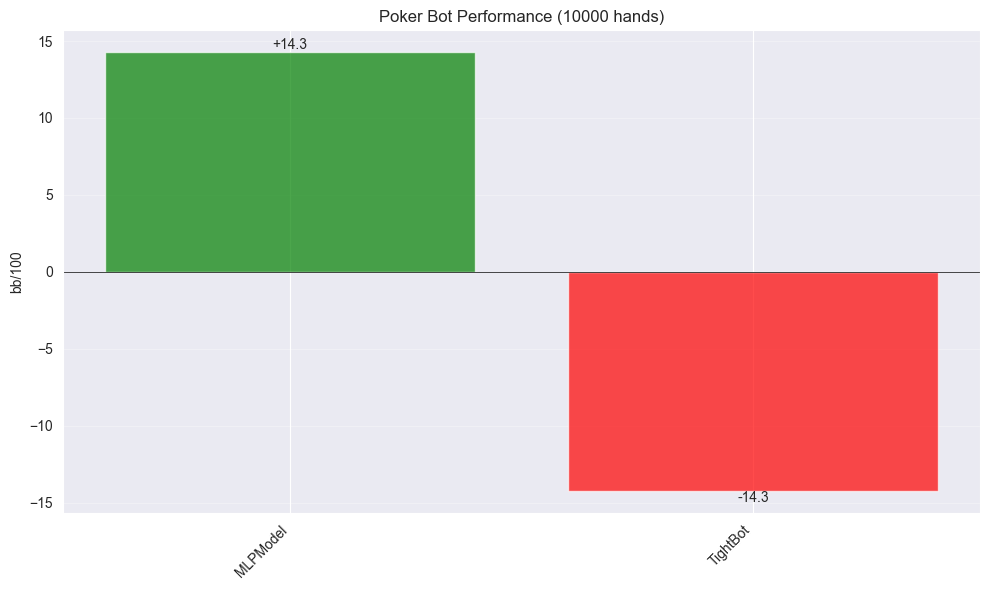


✓ Evaluation complete!


In [20]:
# Cell 18: Visualization
# Results bar chart
fig, ax = plt.subplots(figsize=(10, 6))

player_names = [p.name for p in players]
colors = ['red' if bb < 0 else 'green' for bb in bb_per_100]

bars = ax.bar(player_names, bb_per_100, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('bb/100')
ax.set_title('Poker Bot Performance (10000 hands)')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, bb_per_100):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:+.1f}',
            ha='center', va='bottom' if height > 0 else 'top')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete!")